## 3. Análisis de Componentes Principales

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import seaborn as sb
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import skfuzzy as fuzz
import pylab
import sklearn.mixture as mixture
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import pyclustertend 
import random
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import KMeans, AgglomerativeClustering
from factor_analyzer import calculate_kmo
from factor_analyzer import calculate_bartlett_sphericity
from sklearn.decomposition import PCA


#importar csv
df = pd.read_csv('movies_2026.csv', encoding='latin-1')
pd.options.display.float_format = '{:,.0f}'.format



In [21]:
#3.2
##seleccionar variables numéricas
vars_pca = [
    'budget',
    'revenue',
    'popularity',
    'runtime',
    'voteAvg',
    'voteCount',
    'actorsAmount',
    'castWomenAmount',
    'castMenAmount',
    'genresAmount',
    'productionCoAmount',
    'productionCountriesAmount'
]

X = df[vars_pca].dropna()

In [22]:
#escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
#KMO
kmo_all, kmo_model = calculate_kmo(X)
kmo_model

np.float64(0.8241255711759302)

In [24]:
#Bartlett
chi_square_value, p_value = calculate_bartlett_sphericity(X)
chi_square_value, p_value

(np.float64(105995.94900547608), np.float64(0.0))

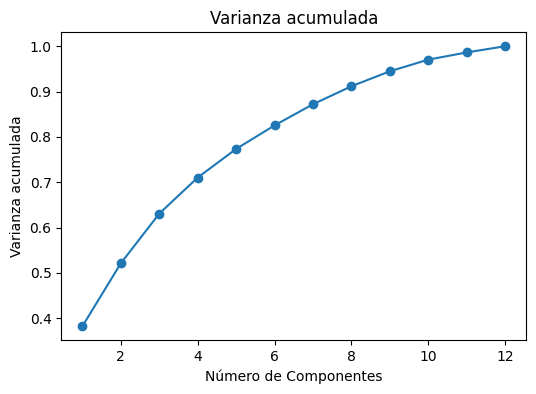

In [25]:
#3.3
## pca
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

plt.figure(figsize=(6,4))
plt.plot(range(1,len(varianza_acum)+1), varianza_acum, marker='o')
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza acumulada")
plt.show()

In [26]:
#componentes que explican >= 80%
np.where(varianza_acum >= 0.8)[0][0] + 1


np.int64(6)

In [28]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(vars_pca))],
    index=vars_pca
)

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
loadings.iloc[:, :6]  # 6 componentes

,PC1,PC2,PC3,PC4,PC5,PC6
budget,0.3423,-0.3278,0.2202,-0.0261,0.1675,0.0927
revenue,0.3210,-0.4043,0.3024,-0.0533,0.1688,0.0429
popularity,0.1198,-0.0702,0.1535,0.9363,-0.2704,0.0158
runtime,0.3326,0.2510,-0.1669,0.0121,-0.0461,0.0121
voteAvg,0.3183,0.3030,-0.1688,0.0937,0.1242,-0.1704
voteCount,0.3435,-0.3246,0.2140,-0.1155,0.0961,0.0521
actorsAmount,0.3872,-0.0219,-0.1302,-0.1660,-0.3833,-0.1886
castWomenAmount,0.3574,0.0936,-0.0797,-0.1704,-0.5152,-0.2287
castMenAmount,0.0015,0.3937,0.6116,-0.0376,0.0748,-0.2665
genresAmount,0.2627,0.1882,-0.2080,0.1690,0.6385,-0.3818
